# Метод главных компонент (PCA)

В этом ноутбуке разберём **метод главных компонент (Principal Component Analysis, PCA)** как классический способ понижения размерности и визуализации данных.

**Цели ноутбука:**
- Понять геометрическую и статистическую интерпретацию PCA.
- Разобрать связь PCA с ковариационной матрицей и сингулярным разложением (SVD).
- Реализовать **PCA с нуля** на `numpy`.
- Сравнить с `PCA` из `sklearn` и визуализировать данные в пространстве главных компонент.

---

**Содержание:** Идея PCA → Ковариация и SVD → Реализация с нуля → Сравнение с sklearn.


## 1. Идея PCA

Пусть есть данные $X \in \mathbb{R}^{N \times d}$ (строки — объекты, столбцы — признаки).
Мы хотим найти новое ортонормированное базисное пространство, в котором:
- первая компонента захватывает **максимальную возможную дисперсию** данных,
- вторая — максимальную дисперсию из оставшейся (ортогонально первой), и так далее.

PCA можно интерпретировать как:
- поиск направлений, в которых данные "наиболее вытянуты" (максимальная вариативность),
- наилучшее (в смысле наименьшей среднеквадратичной ошибки) линейное приближение данных подпространством меньшей размерности.

Практически это означает, что мы ищем матрицу проекции $W \in \mathbb{R}^{d \times k}$, такую что проекция $Z = X W$ сохраняет как можно больше информации (дисперсии) при $k \ll d$.


## 2. Ковариационная матрица, собственные значения и SVD

**Центрирование.** Обычно PCA выполняют над **центрированными** данными: вычитаем среднее по каждому признаку.
Пусть $X_c$ — матрица центрированных данных.

**Ковариационная матрица:**
$$
C = \frac{1}{N - 1} X_c^T X_c.
$$

**Собственные значения и собственные векторы:**
$$
C v_j = \lambda_j v_j.
$$

- $v_j$ — $j$-й собственный вектор (направление главной компоненты),
- $\lambda_j$ — соответствующее собственное значение (дисперсия вдоль этого направления).

Если отсортировать собственные значения по убыванию и взять первые $k$ собственных векторов, получим матрицу $W$ из этих векторов, и проекция $Z = X_c W$ будет содержать первые $k$ главных компонент.

**Связь с SVD.** Сингулярное разложение центрированной матрицы $X_c$:
$$
X_c = U \Sigma V^T,
$$
где строки $V^T$ — правые сингулярные векторы. Они совпадают (с точностью до масштаба) с собственными векторами ковариационной матрицы $C$.
На практике часто используют именно SVD (как делает и `sklearn.PCA`).


## 3. 2D-пример: как выглядят главные компоненты

Начнём с простого 2D-случая, чтобы визуально нарисовать направления главных компонент поверх облака точек.


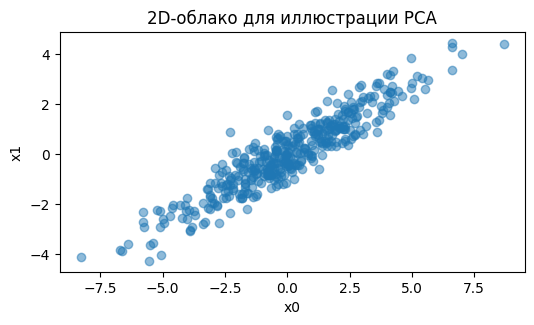

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)

n_samples = 400

# Сильно вытянутое облако в 2D (анизотропное гауссово распределение)
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
scale = np.array([[3.0, 0.0], [0.0, 0.5]])  # вытягивание вдоль первой оси
cov = R @ scale @ scale @ R.T
mean = np.array([0.0, 0.0])

X2d = np.random.multivariate_normal(mean, cov, size=n_samples)

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], alpha=0.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("2D-облако для иллюстрации PCA")
plt.xlabel("x0")
plt.ylabel("x1")
plt.show()


### Главные компоненты как стрелки

Применим `PCA(n_components=2)` и нарисуем:
- облако точек,
- векторы главных компонент, исходящие из среднего.


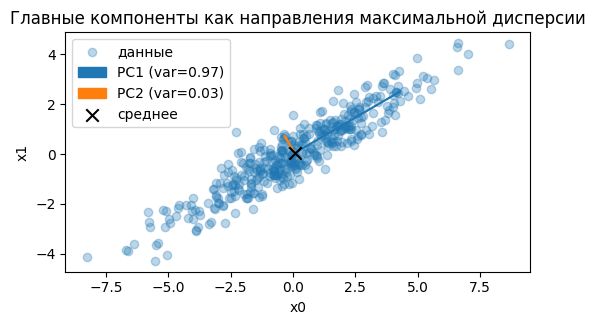

In [2]:
pca2 = PCA(n_components=2)
pca2.fit(X2d)

mean_2d = pca2.mean_
components_2d = pca2.components_  # shape (2, 2)
explained_var_2d = pca2.explained_variance_ratio_

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], alpha=0.3, label="данные")

for i, (vec, var) in enumerate(zip(components_2d, explained_var_2d)):
    length = np.sqrt(var) * 5.0  # масштабируем для наглядности
    arrow = length * vec
    plt.arrow(
        mean_2d[0], mean_2d[1],
        arrow[0], arrow[1],
        width=0.03,
        color="C" + str(i),
        label=f"PC{i+1} (var={var:.2f})",
        length_includes_head=True,
    )

plt.scatter(mean_2d[0], mean_2d[1], color="k", marker="x", s=80, label="среднее")
plt.gca().set_aspect("equal", adjustable="box")
plt.title("Главные компоненты как направления максимальной дисперсии")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()


## 4. Объяснённая дисперсия

Построим:
- столбчатую диаграмму **доли объяснённой дисперсии** для каждой компоненты,
- **накопленную кривую**, чтобы видеть, сколько компонент нужно для объяснения заданной доли вариации.


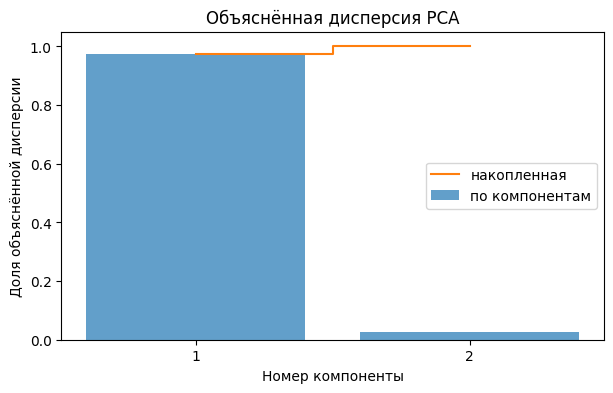

In [3]:
pca_full = PCA()
pca_full.fit(X2d)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)
components = np.arange(1, len(explained) + 1)

plt.figure(figsize=(7, 4))
plt.bar(components, explained, alpha=0.7, label="по компонентам")
plt.step(components, cum_explained, where="mid", color="C1", label="накопленная")
plt.xlabel("Номер компоненты")
plt.ylabel("Доля объяснённой дисперсии")
plt.xticks(components)
plt.ylim(0, 1.05)
plt.title("Объяснённая дисперсия PCA")
plt.legend()
plt.show()


## 5. 3D → 2D: понижение размерности

Теперь возьмём 3D-данные, которые в основном лежат в некоторой двумерной плоскости, и:
- спроецируем их в 2D с помощью PCA,
- сравним 3D-облако и 2D-проекцию.


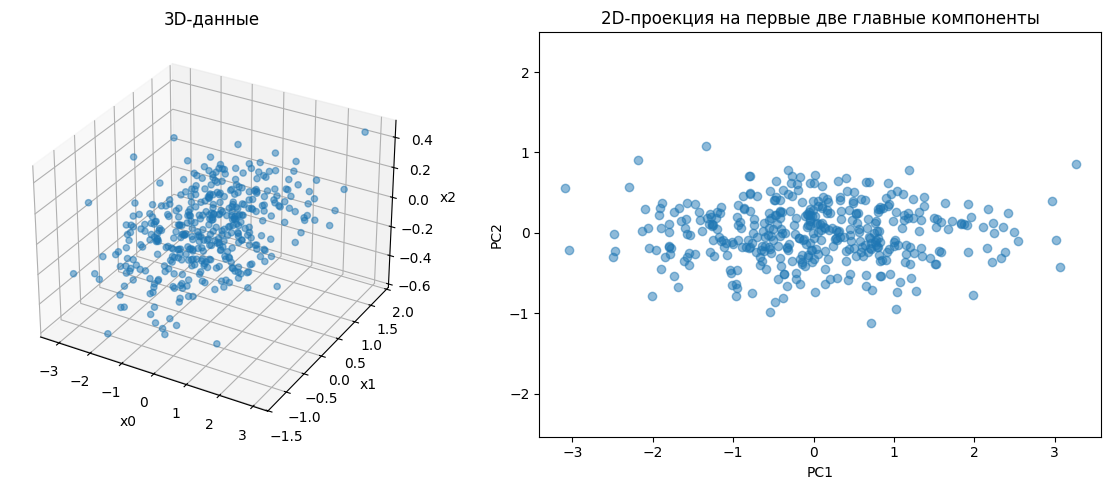

Доля объяснённой дисперсии (PC1, PC2): [0.89852728 0.09381897]


In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(123)

n_samples_3d = 400
u = np.random.randn(n_samples_3d)
v = 0.5 * np.random.randn(n_samples_3d)
X_plane = np.vstack([u, v, 0.1 * np.random.randn(n_samples_3d)])
A = np.array([
    [1.0, 0.5, 0.2],
    [0.2, 0.8, -0.3],
    [0.0, 0.3, 1.0],
])
X3d = (A @ X_plane).T

pca3 = PCA(n_components=2)
Z3 = pca3.fit_transform(X3d)

fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X3d[:, 0], X3d[:, 1], X3d[:, 2], alpha=0.5)
ax.set_title("3D-данные")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("x2")

plt.subplot(1, 2, 2)
plt.scatter(Z3[:, 0], Z3[:, 1], alpha=0.5)
plt.title("2D-проекция на первые две главные компоненты")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axis("equal")

plt.tight_layout()
plt.show()

print("Доля объяснённой дисперсии (PC1, PC2):", pca3.explained_variance_ratio_)


## 6. Восстановление из пониженной размерности

PCA не только понижает размерность, но и позволяет **аппроксимировать исходные данные** из проекции:
- спроецируем 3D-точки в 2D,
- восстановим их обратно в 3D,
- оценим среднеквадратичную ошибку и посмотрим, насколько сильно точки "съехали".


Среднеквадратичная ошибка восстановления из 2D: 0.0034


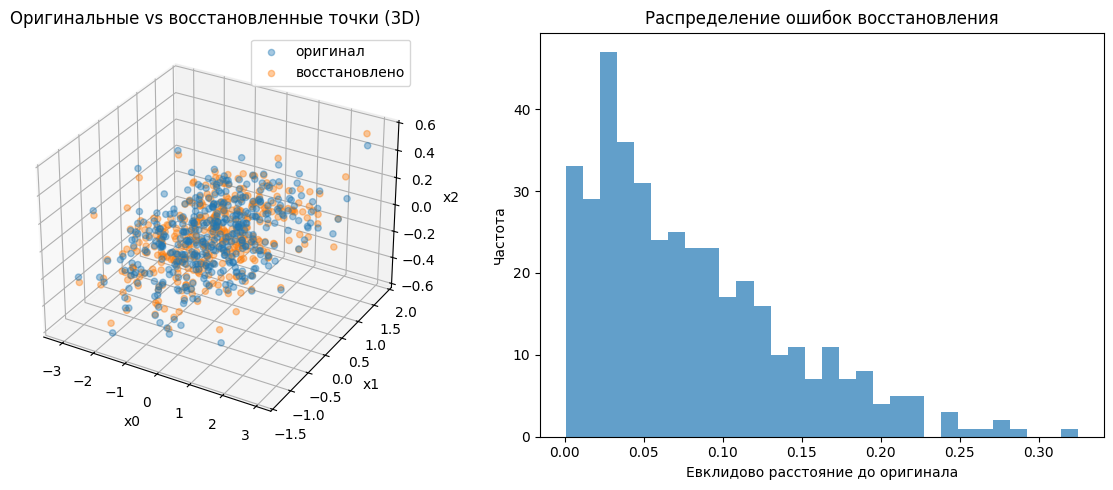

In [5]:
Z_low = Z3  # (n_samples_3d, 2)
W = pca3.components_  # shape (2, 3)
X_rec = Z_low @ W + pca3.mean_

mse = np.mean((X3d - X_rec) ** 2)
print(f"Среднеквадратичная ошибка восстановления из 2D: {mse:.4f}")

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(121, projection="3d")
ax.scatter(X3d[:, 0], X3d[:, 1], X3d[:, 2], alpha=0.4, label="оригинал")
ax.scatter(X_rec[:, 0], X_rec[:, 1], X_rec[:, 2], alpha=0.4, label="восстановлено")
ax.set_title("Оригинальные vs восстановленные точки (3D)")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("x2")
ax.legend()

plt.subplot(122)
plt.hist(np.linalg.norm(X3d - X_rec, axis=1), bins=30, alpha=0.7)
plt.xlabel("Евклидово расстояние до оригинала")
plt.ylabel("Частота")
plt.title("Распределение ошибок восстановления")

plt.tight_layout()
plt.show()


## Выводы

- PCA находит ортонормированные направления максимальной дисперсии; на практике компоненты получают через SVD ковариационной матрицы центрированных данных; их удобно визуализировать как стрелки.
- Число компонент выбирают по графику объяснённой дисперсии или по целевому порогу (например, 95%); на примере 3D→2D качество восстановления можно измерять через MSE.
- Реализация с нуля и sklearn.PCA дают совпадающие по смыслу результаты; PCA полезен для визуализации, сжатия признаков и шумоподавления.